In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [5]:
df_CCI = pd.read_csv('../CCI.csv')
df = pd.read_csv('../dataset.csv')
df_train = pd.read_csv('../features/train.csv')

## Project category

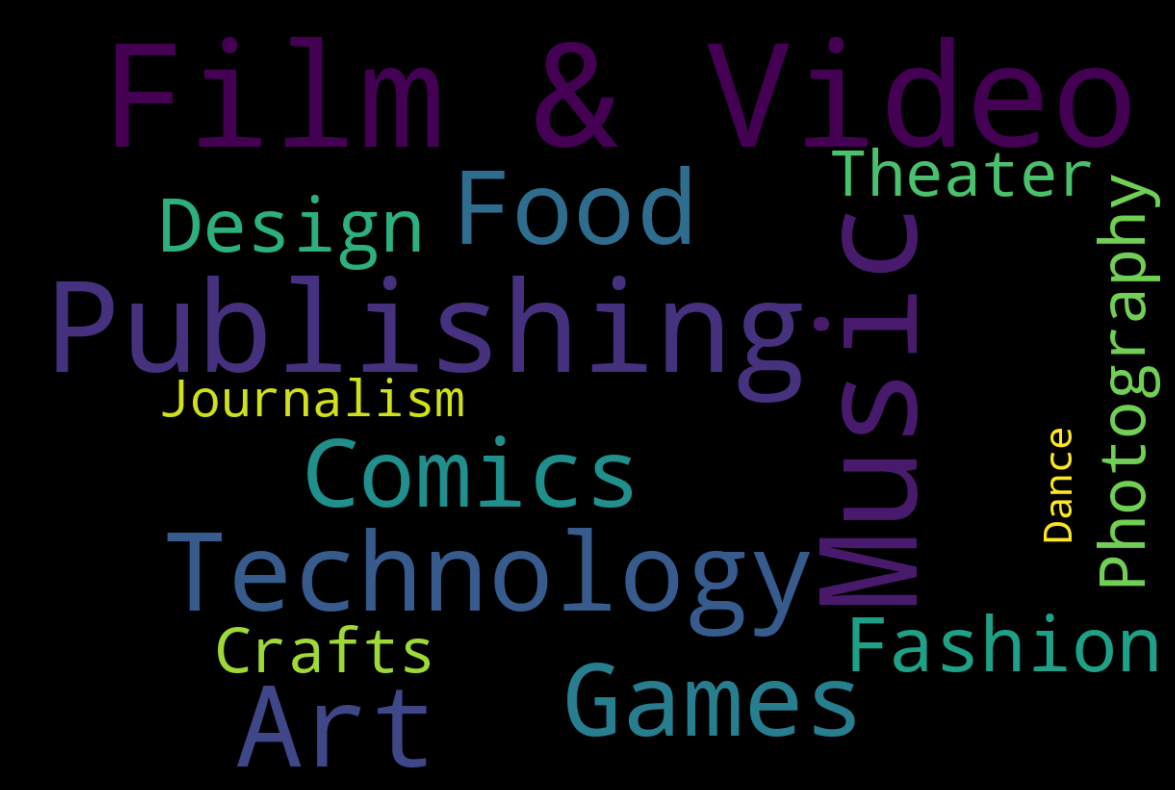

In [6]:
from wordcloud import WordCloud

counts_dict = df['category.parent_name'].value_counts().to_dict()

categories_sorted = sorted(counts_dict.keys(), key=lambda x: counts_dict[x], reverse=True)
num_categories = len(categories_sorted)
cmap = plt.get_cmap('viridis')
color_map = {cat: cmap(i / (num_categories - 1)) for i, cat in enumerate(categories_sorted)}

def viridis_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    rgba_color = color_map.get(word, (1, 1, 1, 1))
    return tuple(int(c * 255) for c in rgba_color[:3])

wc = WordCloud(
    background_color='black',
    color_func=viridis_color_func,
    width=1200, height=800,
    max_font_size=150,
    min_font_size=20,
    random_state=42,
    prefer_horizontal=0.7,
    collocations=False
)

wc.generate_from_frequencies(counts_dict)

fig, ax = plt.subplots(figsize=(15, 8), facecolor='black')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

plt.tight_layout()
plt.show()

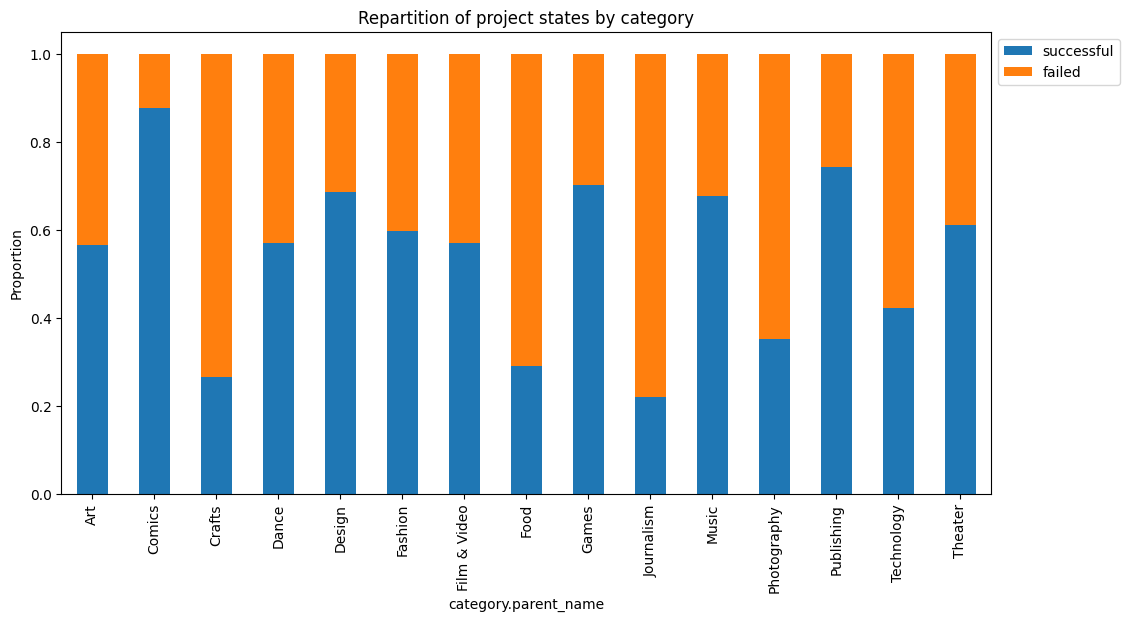

In [7]:
repartition_pct = pd.crosstab(df['category.parent_name'], df['state'], normalize='index')

repartition_pct.iloc[:, ::-1].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Repartition of project states by category")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel("Proportion")
plt.show()

## Goal & Pledged

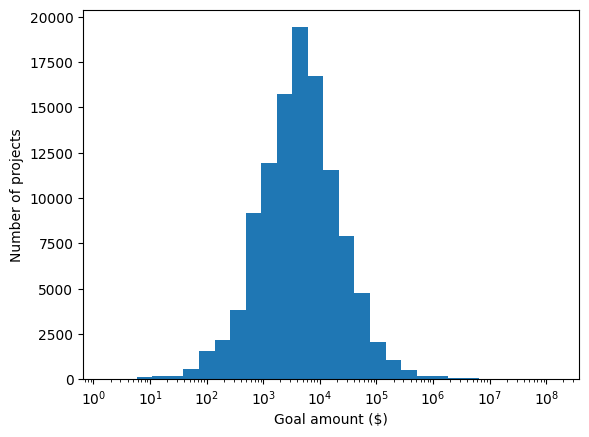

In [8]:
bins = np.logspace(np.log10(df["goal_usd"].min() + 1), 
                   np.log10(df["goal_usd"].max()), 
                   30)

plt.hist(df["goal_usd"], bins=bins)
plt.xscale('log')

plt.xlabel("Goal amount ($)")
plt.ylabel("Number of projects")
plt.show()

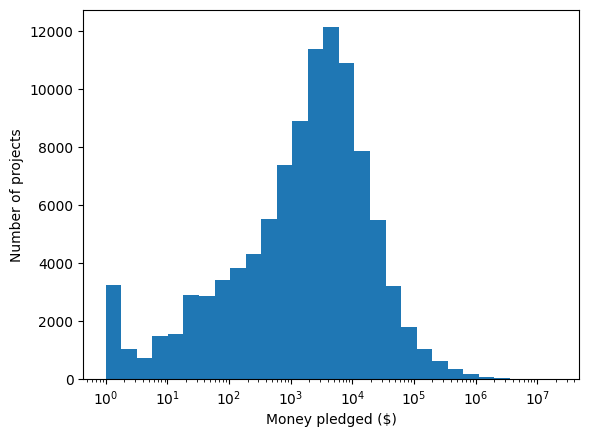

In [9]:
bins = np.logspace(np.log10(df["pledged_usd"].min() + 1), 
                   np.log10(df["pledged_usd"].max()), 
                   30)

plt.hist(df["pledged_usd"], bins=bins)
plt.xscale('log')

plt.xlabel("Money pledged ($)")
plt.ylabel("Number of projects")
plt.show()

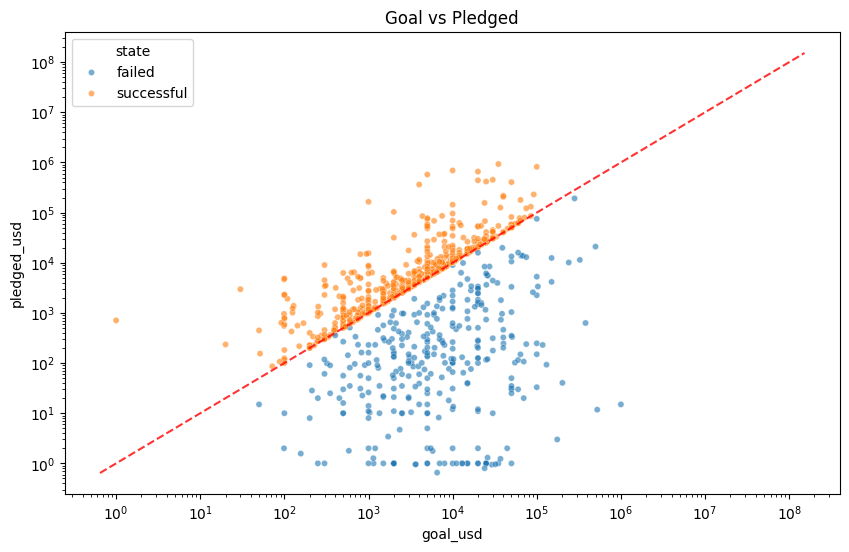

In [10]:
df_sample = df.sample(n=1000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x="goal_usd", y="pledged_usd", alpha=0.6, hue="state", s=20)

plt.xscale('log')
plt.yscale('log')

# Ligne de succès
limits = [df["goal_usd"].min(), df["goal_usd"].max()]
plt.plot(limits, limits, color='red', linestyle='--', alpha=0.8)

plt.title("Goal vs Pledged")
plt.show()